## Domain Analysis

1) What is Compressive Strength?
   Compressive Strength measures how much load concrete can withstand before it breaks or cracks.
  - It is measured in:
  - MPa (Megapascal)
  - Higher MPa means stronger concrete.

Examples:

## Strength (MPa)	Usage
# 20-30 MPa	Residential buildings
# 30-50 MPa	Commercial structures
# 50+ MPa	Bridges and heavy structures

- The target variable in this project is:

- Concrete Compressive Strength (MPa)

# 3. Why Predict Strength?

Traditionally, engineers:

Create concrete mix.
Wait several days/weeks.
Test strength in laboratory.

This process:

Takes time
Costs money
Requires physical testing

Machine Learning can predict strength directly from the ingredients and age of concrete.

Benefits:

Faster decision making
Reduced testing cost
Better mix design optimization

## How Concrete Gains Strength

The process is called:

Hydration

When cement reacts with water:

- Cement + Water
       ↓
- Hydration Reaction
       ↓
- Hardening
       ↓
- Strength Development

As hydration continues:

Concrete becomes harder
Strength increases

This is why Age is a crucial feature.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
df = pd.read_csv("concrete.csv")

In [39]:
df.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [40]:
df.tail()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77
1029,260.9,100.5,78.3,200.6,8.6,864.5,761.5,28,32.40


In [41]:
df.shape

(1030, 9)

In [42]:
df.describe()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [44]:
df.isnull().sum()

cement          0
slag            0
ash             0
water           0
superplastic    0
coarseagg       0
fineagg         0
age             0
strength        0
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(25)

In [46]:
df.drop_duplicates(inplace = True)

In [47]:
df.duplicated().sum()

np.int64(0)

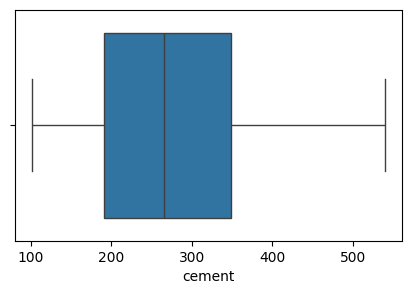

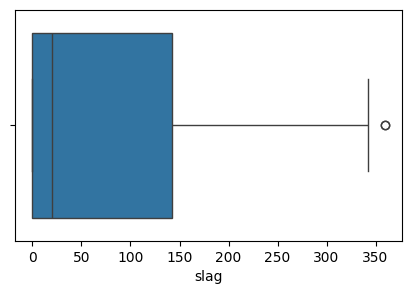

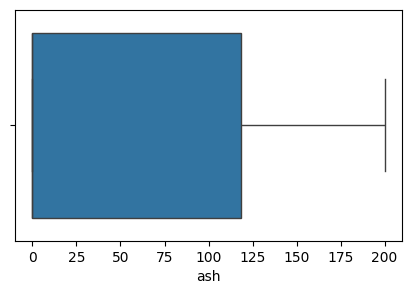

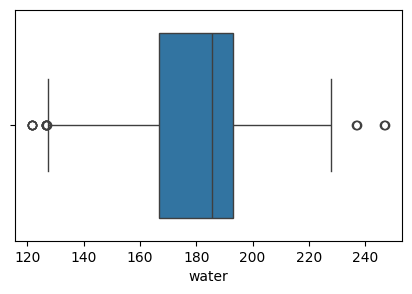

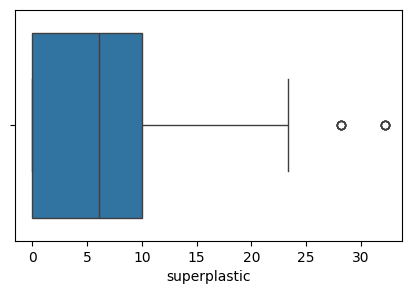

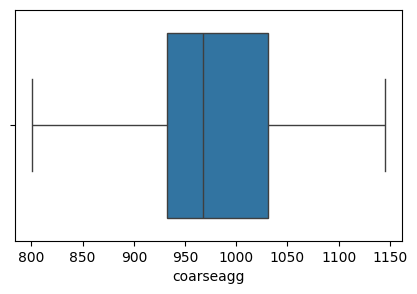

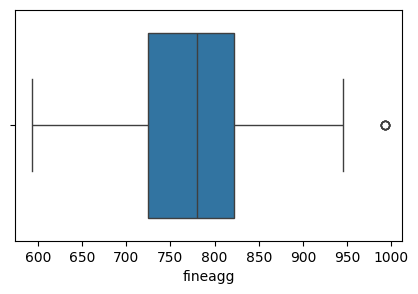

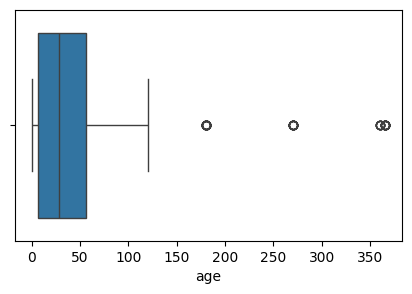

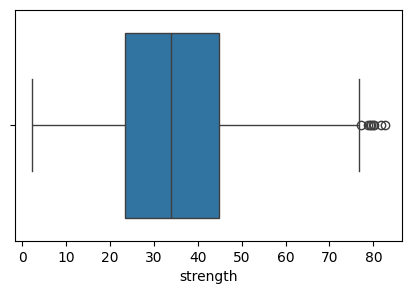

In [48]:
for col in df.columns:
    plt.figure(figsize=(5,3))
    sns.boxplot(x = df[col])
    plt.show()

<Axes: xlabel='strength', ylabel='Count'>

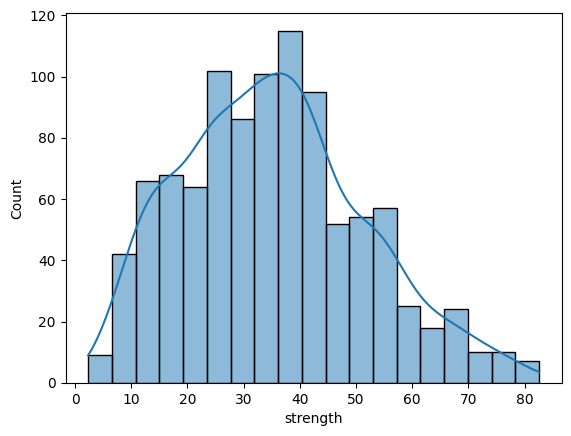

In [49]:
sns.histplot(df['strength'], kde = True)

<Axes: xlabel='cement', ylabel='Count'>

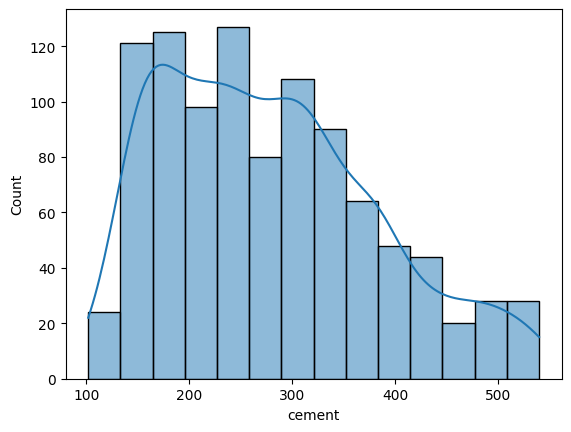

In [50]:
sns.histplot(df['cement'], kde = True)

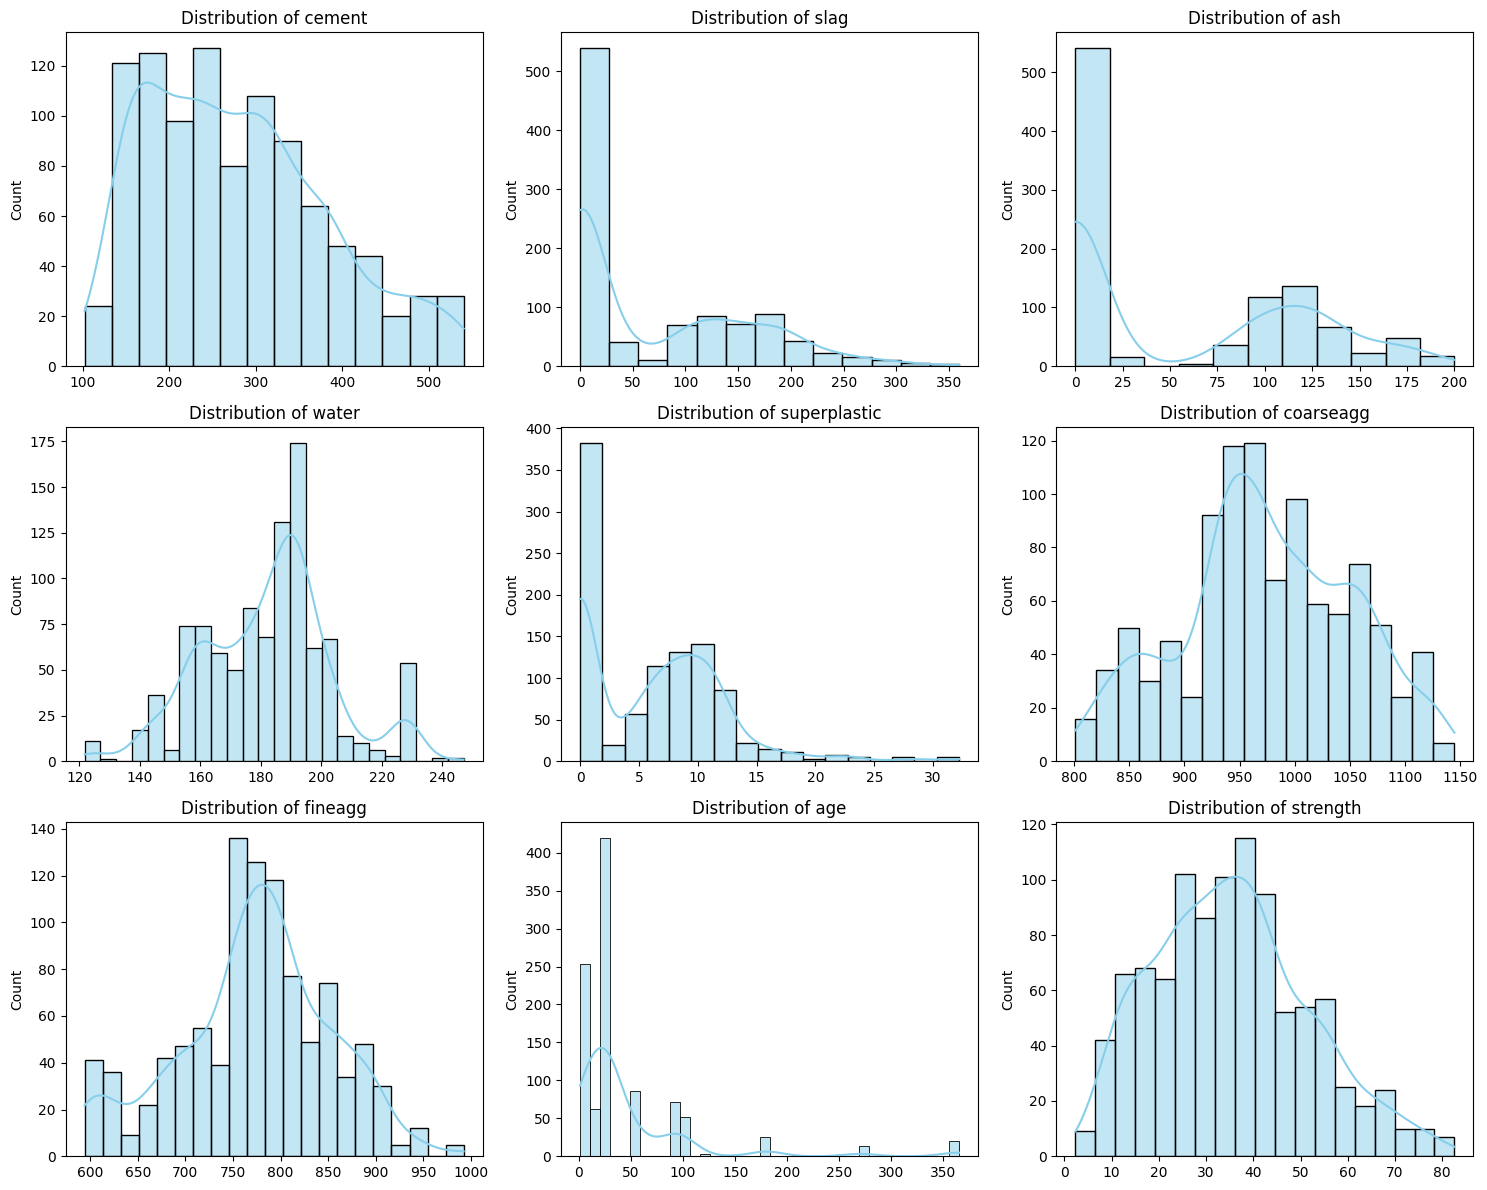

In [51]:

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))


axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('') 
    axes[i].set_ylabel('Count')

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()


In [65]:
df.skew(numeric_only=True)

cement                0.564959
slag                  0.855225
ash                   0.497231
water                 0.034433
superplastic          0.980604
coarseagg            -0.065256
fineagg              -0.252353
age                   3.253974
strength              0.395696
Water_Cement_Ratio    0.940469
Total_Binder          0.391346
dtype: float64

# Insight
### Right Skewed data
- slag: Strongly right-skewed. A massive peak at 0
- ash: Strongly right-skewed. Similar to slag, many mixes have 0 fly ash, with a tail stretching out.
- superplastic: Strongly right-skewed. A huge spike at 0 (no superplasticizer) and a tail tapering off past 20.
- age: Extremely right-skewed. The vast majority of concrete samples are tested early on (e.g., 28 days or less), while only a few are left to cure for 90 to 365 days.

### Normal Distribution 
- water
- coarseagg
- fineagg
- strength

## Correlation Matrix

<Axes: >

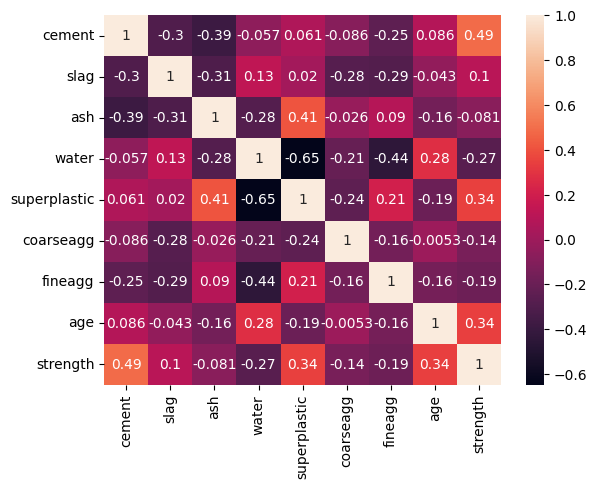

In [53]:
sns.heatmap(df.corr(), annot= True,)

### Insight
- Cement positively affects strength.
- Age positively affects strength.
- Water negatively affects strength.

In [54]:
print(df.columns)

Index(['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg',
       'fineagg', 'age', 'strength'],
      dtype='object')


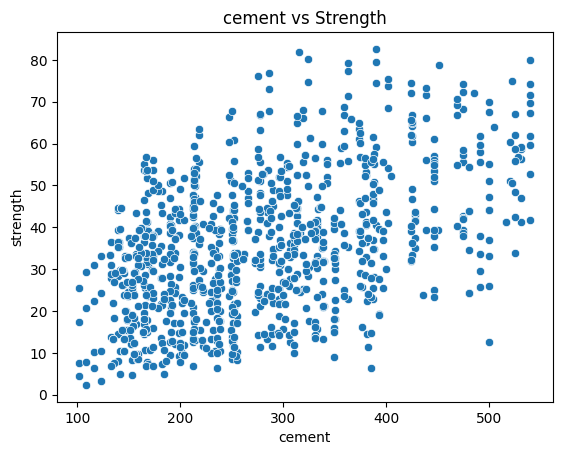

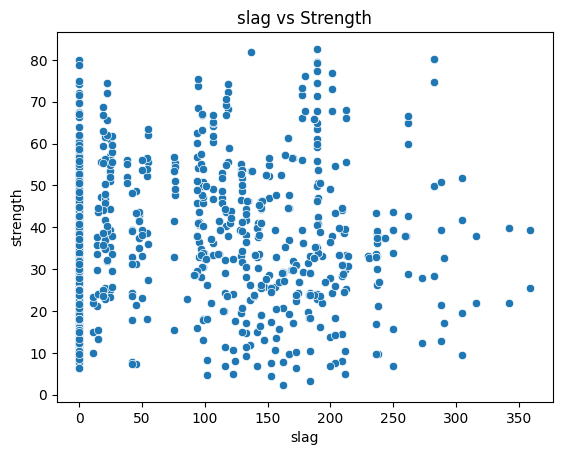

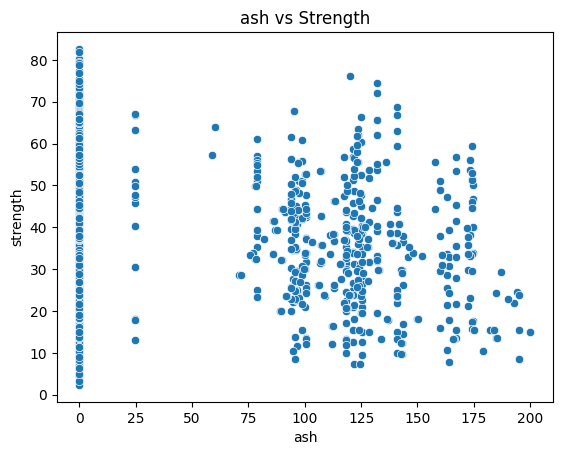

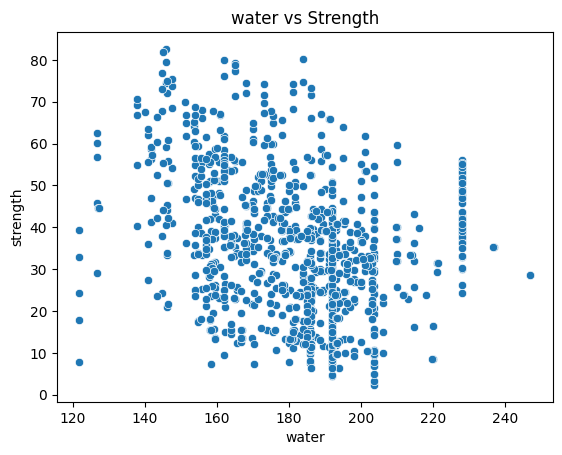

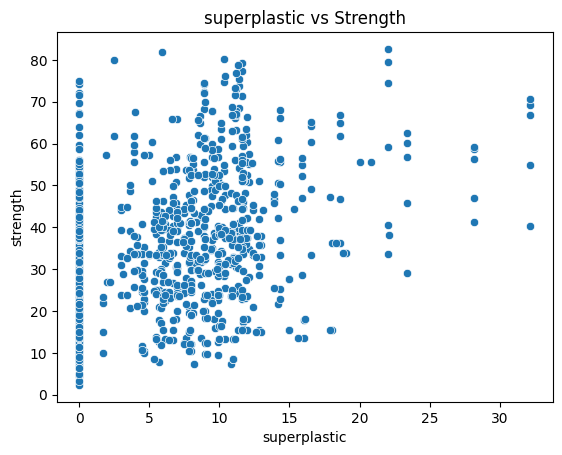

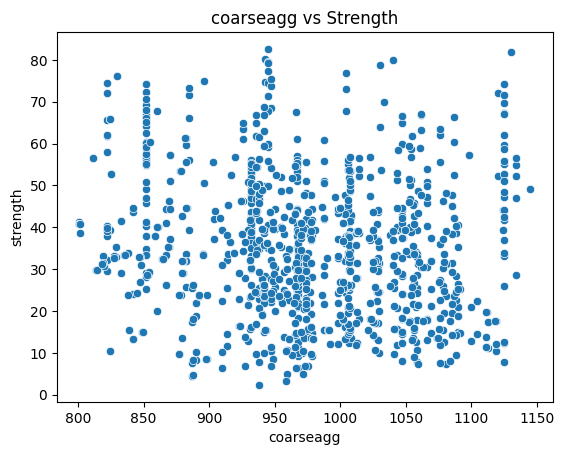

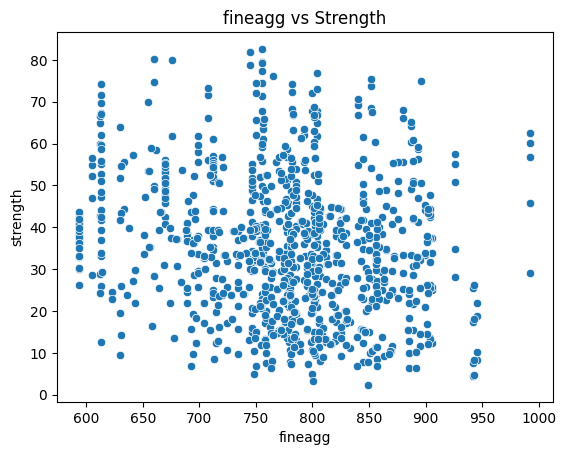

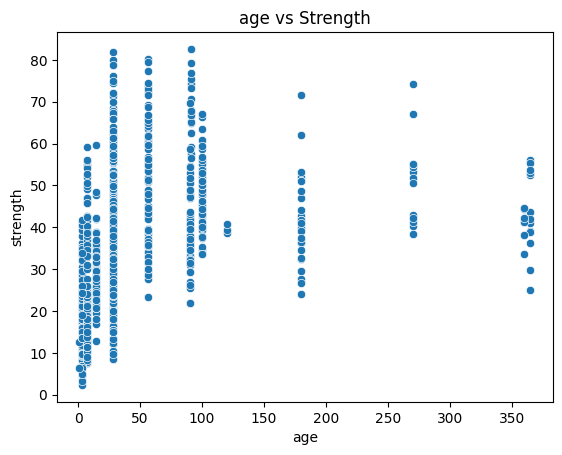

In [55]:
features = df.columns[:-1]

for col in features:
    sns.scatterplot(
        x=df[col],
        y=df['strength']
    )
    plt.title(f"{col} vs Strength")
    plt.show()

In [56]:
df.columns

Index(['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg',
       'fineagg', 'age', 'strength'],
      dtype='object')

## Feature Engineering

In [57]:
df['Water_Cement_Ratio']= (df['water']/df['cement'])

In [61]:
df.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength,Water_Cement_Ratio,Total_Binder
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,0.300000,540.0
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,0.300000,540.0
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,0.685714,475.0
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,0.685714,475.0
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,0.966767,331.0


In [60]:
df['Total_Binder'] = (
    df['cement']
    + df['slag']
    + df['ash']
)

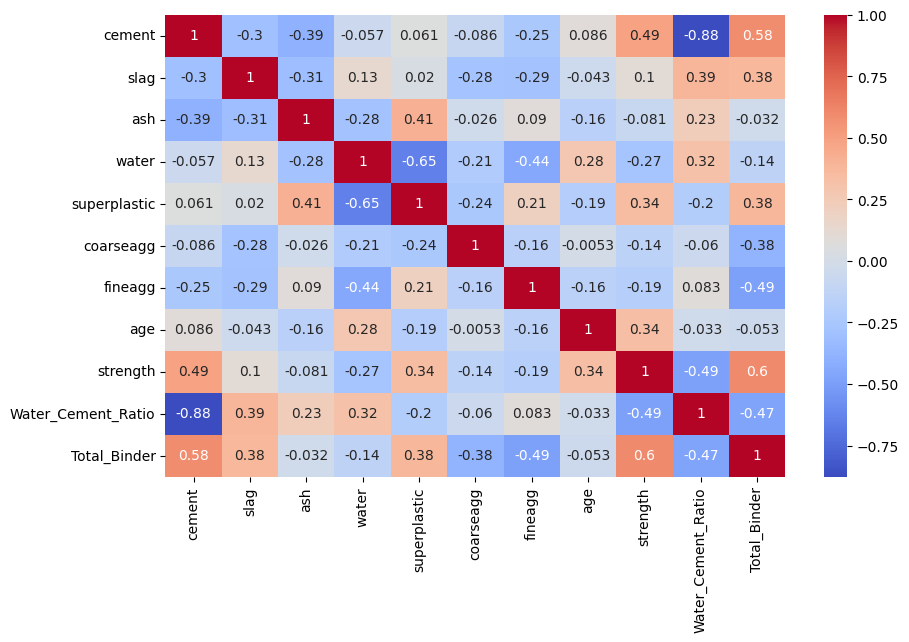

In [62]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

<Axes: xlabel='Water_Cement_Ratio', ylabel='Count'>

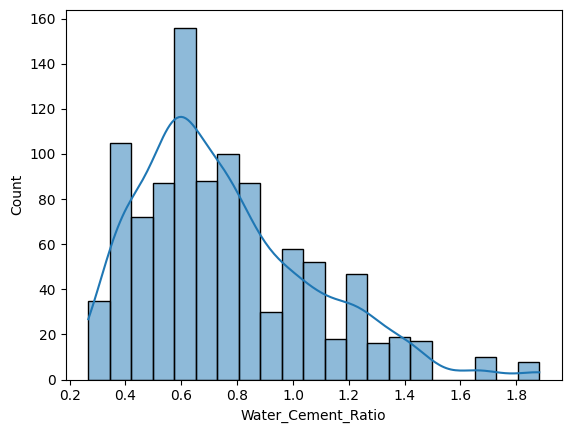

In [64]:
sns.histplot(df['Water_Cement_Ratio'], kde = True)

<Axes: xlabel='Total_Binder', ylabel='Count'>

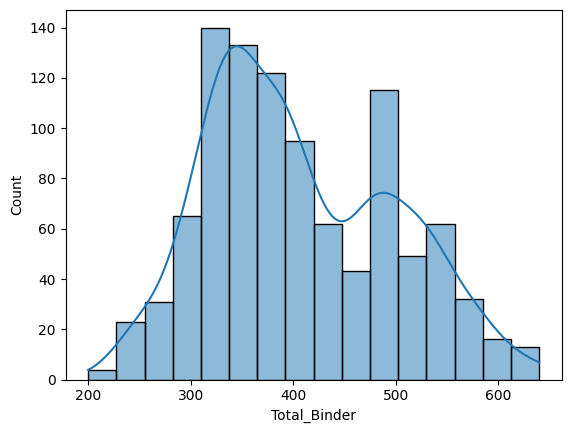

In [66]:
sns.histplot(df['Total_Binder'], kde = True)

## Train test split

In [67]:
x = df.drop(columns = ['strength'])
y = df['strength']

In [68]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [70]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()


X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

In [83]:
model = {
    "Linear regression" : LinearRegression(),
    "Random Forest" : RandomForestRegressor(random_state = 42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

for name, model in model.items():
    model.fit(X_train_scaled,y_train)
    prediction = model.predict(X_test_scaled)
    r2 = r2_score(y_test, prediction)
    mae = mean_absolute_error(y_test, prediction)
    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    
    print(f"=== {name} ===")
    print(f"R² Score: {r2:.4f}")
    print(f"Mean Absolute Error: {mae:.2f} MPa\n")
    print(f"Root Mean Squared Error: {rmse:.2f} MPa\n")
    

=== Linear regression ===
R² Score: 0.5849
Mean Absolute Error: 8.83 MPa

Root Mean Squared Error: 11.13 MPa

=== Random Forest ===
R² Score: 0.9201
Mean Absolute Error: 3.43 MPa

Root Mean Squared Error: 4.88 MPa

=== Gradient Boosting ===
R² Score: 0.9055
Mean Absolute Error: 3.90 MPa

Root Mean Squared Error: 5.31 MPa



In [ ]:
import pickle
import json
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Save the RobustScaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Saved scaler.pkl")

# 2. Train and save the best model (Random Forest)
best_model = RandomForestRegressor(random_state=42)
best_model.fit(X_train_scaled, y_train)

with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("Saved model.pkl")

# 3. Save model metadata (metrics & feature importances) for the frontend dashboard
predictions = best_model.predict(X_test_scaled)
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

importances = best_model.feature_importances_
features = list(x.columns)
feature_importances = sorted(
    [{"name": name, "importance": float(imp)} for name, imp in zip(features, importances)],
    key=lambda k: k['importance'],
    reverse=True
)

metadata = {
    "metrics": {
        "r2_score": float(r2),
        "mae_mpa": float(mae),
        "rmse_mpa": float(rmse)
    },
    "features": features,
    "feature_importances": feature_importances
}

with open('model_meta.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print("Saved model_meta.json")